In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql import *
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
spark = SparkSession.builder.appName("Bus Delay Modeling").getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "UTC")

model_data = spark.read.parquet("Data/Processed/model_features")
print("Rows:", model_data.count())
model_data.printSchema()
model_data.show(5)

Rows: 2691
root
 |-- route_id: string (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- time_diff_secs: integer (nullable = true)
 |-- delay_min: double (nullable = true)
 |-- RecordedTime_ts: timestamp (nullable = true)

+--------+---------+----+--------------------+--------------+-------------------+-------------------+
|route_id|agency_id|hour|         distance_km|time_diff_secs|          delay_min|    RecordedTime_ts|
+--------+---------+----+--------------------+--------------+-------------------+-------------------+
|   24217|    OP258|  17|  0.1962854250327797|           185|-3.0833333333333335|2026-07-02 17:40:55|
|   59188|    OP258|  17|0.017434665396107073|            34|-0.5666666666666667|2026-07-02 17:12:26|
|   58853|    OP258|  16| 0.04546275741983961|            92|-1.5333333333333334|2026-07-02 16:01:28|
|   59235|    OP258|  17|    0.27921676648527|          1031| 17.1833333

In [11]:
model_pd = model_data.toPandas()

model_pd["RecordedTime_ts"] = pd.to_datetime(
    model_pd["RecordedTime_ts"]
).dt.tz_localize(None)
disruption = pd.read_csv("Data/Processed/disruption_clean.csv")

disruption["CreationTime"] = pd.to_datetime(
    disruption["CreationTime"],
    format="mixed"
).dt.tz_localize(None)

In [12]:
disruption_times = disruption["CreationTime"].values.astype("datetime64[s]")

def has_nearby_disruption(recorded_time, window_hours=6):
    diff = np.abs(
        (
            disruption_times -
            np.datetime64(recorded_time)
        ).astype("timedelta64[s]").astype(int)
    )

    return int((diff <= window_hours * 3600).any())

model_pd["disruption_active"] = model_pd["RecordedTime_ts"].apply(
    has_nearby_disruption
)

print(model_pd["disruption_active"].value_counts())

disruption_active
1    2016
0     675
Name: count, dtype: int64


In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon / 2) ** 2
    )
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

In [14]:
# Load datasets
bus_schedule = spark.read.parquet("Data/Processed/bus_schedule")

agency = spark.read.option("header", True).csv("Data/Raw/agency.txt")

routes = spark.read.option("header", True).csv("Data/Raw/routes.txt")

vehicle_spark = spark.read.csv(
    "Data/Processed/vehicle_clean.csv",
    header=True,
    inferSchema=True
)
# Match vehicle with agency
vehicle_with_agency = vehicle_spark.join(
    agency,
    upper(trim(vehicle_spark.Operator)) == upper(trim(agency.agency_noc)),
    "left"
)

matched = vehicle_with_agency.join(
    routes,
    (vehicle_with_agency.agency_id == routes.agency_id) &
    (upper(trim(vehicle_with_agency.LineRef)) == upper(trim(routes.route_short_name))),
    "inner"
).drop(routes.agency_id)

print("Matched Records :", matched.count())
print("Vehicle Records :", vehicle_spark.count())

Matched Records : 3768
Vehicle Records : 27488


In [15]:
candidates = matched.join(
    bus_schedule.drop(
        "agency_id",
        "route_short_name",
        "route_long_name",
        "route_type"
    ),
    "route_id"
)
candidates = candidates.withColumn(
    "distance_km",
    expr("""
    6371 * 2 * asin(
        sqrt(
            pow(sin(radians(stop_lat - Latitude)/2),2)
            +
            cos(radians(Latitude))
            *
            cos(radians(stop_lat))
            *
            pow(sin(radians(stop_lon - Longitude)/2),2)))
            """)
)
candidates = candidates.filter(col("distance_km") <= 0.6)


In [16]:
candidates = candidates.withColumn(
    "RecordedTime_ts",
    to_timestamp("RecordedTime")
)
candidates = candidates.withColumn(
    "recorded_secs",
    hour("RecordedTime_ts")*3600 +
    minute("RecordedTime_ts")*60 +
    second("RecordedTime_ts")
)

time_parts = split(col("arrival_time"), ":")

candidates = candidates.withColumn(
    "scheduled_secs",
    time_parts.getItem(0).cast("int")*3600 +
    time_parts.getItem(1).cast("int")*60 +
    time_parts.getItem(2).cast("int")
)

candidates = candidates.withColumn(
    "time_diff_secs",
    abs(col("recorded_secs") - col("scheduled_secs"))
)

In [17]:
window_spec = Window.partitionBy(
    "VehicleRef",
    "RecordedTime"
).orderBy("time_diff_secs")

nearest_stop = candidates.withColumn(
    "rn",
    row_number().over(window_spec)
).filter(col("rn") == 1)

nearest_stop = nearest_stop.withColumn(
    "delay_min",
    (col("recorded_secs") - col("scheduled_secs"))/60
)

nearest_stop = nearest_stop.filter(abs(col("delay_min")) <= 120)

nearest_stop = nearest_stop.filter(col("time_diff_secs") <= 3600)

nearest_stop = nearest_stop.withColumn(
    "hour",
    hour("RecordedTime_ts")
)

print("Recovered Rows :", nearest_stop.count())

Recovered Rows : 3041


In [18]:
model_pd_v2 = nearest_stop.select(
    "route_id",
    "agency_id",
    "hour",
    "distance_km",
    "time_diff_secs",
    "delay_min",
    "RecordedTime_ts",
    "direction_id",
    "route_type",
    "stop_sequence",
    "pickup_type",
    "drop_off_type",
    "wheelchair_boarding"

).toPandas()
model_pd_v2["RecordedTime_ts"] = pd.to_datetime(
    model_pd_v2["RecordedTime_ts"]
)
model_pd_v2["disruption_active"] = model_pd_v2[
    "RecordedTime_ts"
].apply(has_nearby_disruption)

print(model_pd_v2.shape)

model_pd_v2.head()

(3041, 14)


,route_id,agency_id,hour,distance_km,time_diff_secs,delay_min,RecordedTime_ts,direction_id,route_type,stop_sequence,pickup_type,drop_off_type,wheelchair_boarding,disruption_active
0,24217,OP258,17,0.549210,5,-0.083333,2026-07-02 17:40:55,0,3,30,0,0,0,1
1,59188,OP258,17,0.017435,34,-0.566667,2026-07-02 17:12:26,1,3,12,0,0,0,1
2,58853,OP258,16,0.305034,32,-0.533333,2026-07-02 16:01:28,1,3,34,0,0,0,1
3,59188,OP258,17,0.568650,330,-5.500000,2026-07-02 17:33:30,0,3,16,0,0,0,1
4,59235,OP258,17,0.279217,1031,17.183333,2026-07-02 17:23:11,1,3,2,0,0,0,1


# Feature Engineering

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
model_pd_v2["minute"] = model_pd_v2["RecordedTime_ts"].dt.minute

model_pd_v2["day_of_week"] = model_pd_v2["RecordedTime_ts"].dt.dayofweek

model_pd_v2["is_peak_hour"] = (
    ((model_pd_v2["hour"] >= 7) & (model_pd_v2["hour"] <= 9)) |
    ((model_pd_v2["hour"] >= 16) & (model_pd_v2["hour"] <= 19))
).astype(int)

model_pd_v2["is_weekend"] = (
    model_pd_v2["day_of_week"] >= 5
).astype(int)

# Traffic density
model_pd_v2["traffic_density"] = (
    model_pd_v2.groupby(["hour","route_id"])
    ["route_id"]
    .transform("count")
)
model_pd_v2["time_of_day"] = pd.cut(
    model_pd_v2["hour"],
    bins=[0,6,10,16,20,24],
    labels=[0,1,2,3,4],
    include_lowest=True
).astype(int)

# Distance per stop
model_pd_v2["distance_per_stop"] = (
    model_pd_v2["distance_km"] /
    (model_pd_v2["stop_sequence"] + 1)
)

# Hour × Distance interaction
model_pd_v2["hour_distance"] = (
    model_pd_v2["hour"] *
    model_pd_v2["distance_km"]
)

# Encode Categorical Features
route_encoder = LabelEncoder()
agency_encoder = LabelEncoder()

model_pd_v2["route_id_enc"] = route_encoder.fit_transform(
    model_pd_v2["route_id"].astype(str)
)

model_pd_v2["agency_id_enc"] = agency_encoder.fit_transform(
    model_pd_v2["agency_id"].astype(str)
)

# Handle Missing Values
model_pd_v2 = model_pd_v2.fillna(0)
# Remove extreme delays
model_pd_v2["delay_min"] = model_pd_v2["delay_min"].clip(-30,30)
# Select Features
features = [
    "route_id_enc",
    "agency_id_enc",
    "hour",
    "minute",
    "distance_km",
    "traffic_density",
    "distance_per_stop",
    "hour_distance",
    "stop_sequence",
    "pickup_type",
    "drop_off_type",
    "is_peak_hour",
    "day_of_week",
    "is_weekend",
    "time_of_day"
]

X = model_pd_v2[features]
y = model_pd_v2["delay_min"]


# Train / Test Split

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("Features Used    :", len(features))
print(features)

Training Samples : 2432
Testing Samples  : 609
Features Used    : 15
['route_id_enc', 'agency_id_enc', 'hour', 'minute', 'distance_km', 'traffic_density', 'distance_per_stop', 'hour_distance', 'stop_sequence', 'pickup_type', 'drop_off_type', 'is_peak_hour', 'day_of_week', 'is_weekend', 'time_of_day']


# Baseline Model (Linear Regression)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance")
print(f"RMSE : {lr_rmse:.3f}")
print(f"MAE  : {lr_mae:.3f}")
print(f"R²   : {lr_r2:.3f}")

Linear Regression Performance
RMSE : 9.330
MAE  : 5.786
R²   : 0.220


In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:", cv_scores)
print("Average R²:", cv_scores.mean())

Cross Validation R² Scores: [0.25271259 0.17299613 0.28167109 0.24908157 0.24556574]
Average R²: 0.24040542629637604


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest")
print(f"RMSE: {rf_rmse:.3f}  MAE: {rf_mae:.3f}  R²: {rf_r2:.3f}")

Random Forest
RMSE: 8.632  MAE: 4.792  R²: 0.332


In [25]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest CV Scores:", rf_cv)
print("Average R²:", rf_cv.mean())

Random Forest CV Scores: [0.33646212 0.44311255 0.42475661 0.40225355 0.45098104]
Average R²: 0.4115131726334088


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gbt = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    random_state=42
)
gbt.fit(X_train, y_train)
gbt_preds = gbt.predict(X_test)

gbt_rmse = np.sqrt(mean_squared_error(y_test, gbt_preds))
gbt_mae = mean_absolute_error(y_test, gbt_preds)
gbt_r2 = r2_score(y_test, gbt_preds)

print("Gradient Boosted Trees")
print(f"RMSE: {gbt_rmse:.3f}  MAE: {gbt_mae:.3f}  R²: {gbt_r2:.3f}")

Gradient Boosted Trees
RMSE: 8.918  MAE: 4.957  R²: 0.287


In [27]:
gb_cv = cross_val_score(
    gbt,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Gradient Boosting CV Scores:", gb_cv)
print("Average R²:", gb_cv.mean())

Gradient Boosting CV Scores: [0.28480294 0.42023706 0.40154588 0.3777443  0.43012078]
Average R²: 0.3828901926702179


                    Model      RMSE       MAE        R2
0       Linear Regression  9.329584  5.785935  0.220237
1           Random Forest  8.632492  4.792026  0.332409
2  Gradient Boosted Trees  8.918425  4.956600  0.287452
hour                 0.218916
time_of_day          0.120408
distance_per_stop    0.114977
hour_distance        0.096244
stop_sequence        0.088831
distance_km          0.088069
route_id_enc         0.070320
agency_id_enc        0.065241
minute               0.059500
traffic_density      0.029210
is_peak_hour         0.022288
pickup_type          0.018139
drop_off_type        0.006097
day_of_week          0.001760
is_weekend           0.000000
dtype: float64


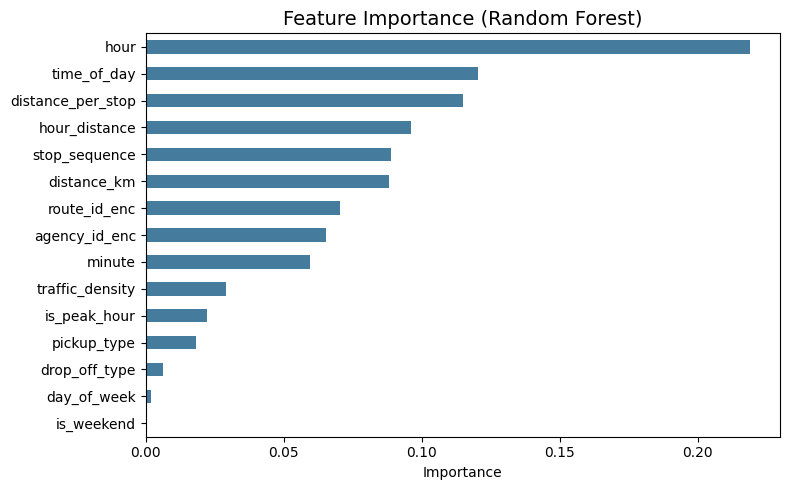

In [28]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosted Trees"],
    "RMSE": [lr_rmse, rf_rmse, gbt_rmse],
    "MAE":  [lr_mae, rf_mae, gbt_mae],
    "R2":   [lr_r2, rf_r2, gbt_r2]
})
print(results)

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
importances.plot(kind="barh", color="#457b9d")
plt.title("Feature Importance (Random Forest)", fontsize=14)
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Visualizations/feature_importance_v2.png", dpi=300, bbox_inches="tight")
plt.show()

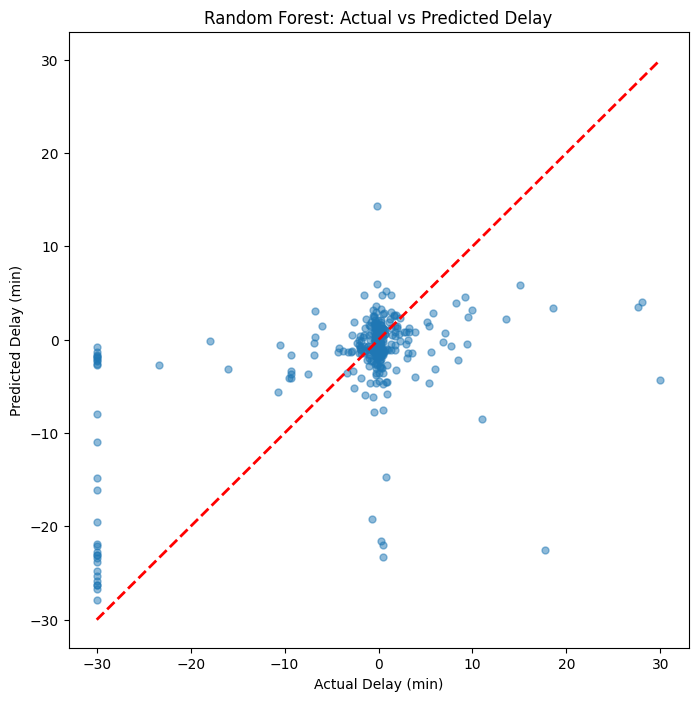

In [29]:
plot_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_preds
})

plot_df = plot_df.sample(n=300, random_state=42) 

plt.figure(figsize=(8,8))

plt.scatter(
    plot_df["Actual"],
    plot_df["Predicted"],
    s=25,
    alpha=0.5
)

lims = [
    np.min([plot_df["Actual"].min(), plot_df["Predicted"].min()]),
    np.max([plot_df["Actual"].max(), plot_df["Predicted"].max()])
]

plt.plot(lims, lims, "r--", linewidth=2)

plt.xlabel("Actual Delay (min)")
plt.ylabel("Predicted Delay (min)")
plt.title("Random Forest: Actual vs Predicted Delay")

plt.show()

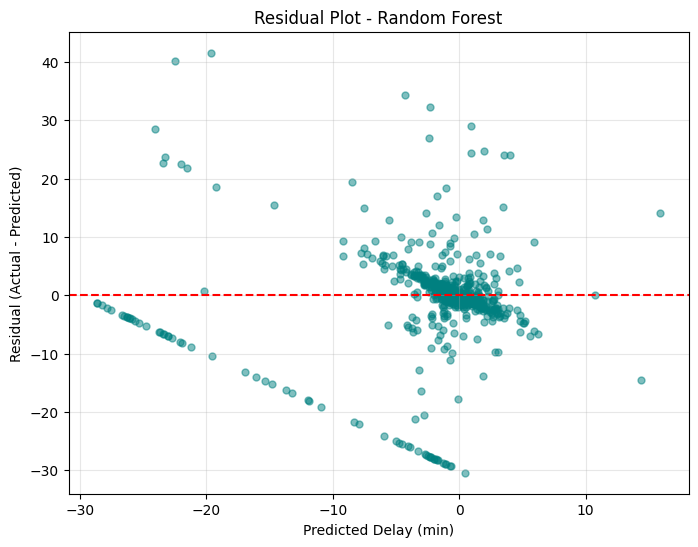

In [30]:
# Residual plot
residuals = y_test - rf_preds

plt.figure(figsize=(8,6))

plt.scatter(
    rf_preds,
    residuals,
    alpha=0.5,
    s=25,
    color="teal"
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Delay (min)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Random Forest")

plt.grid(alpha=0.3)
plt.show()

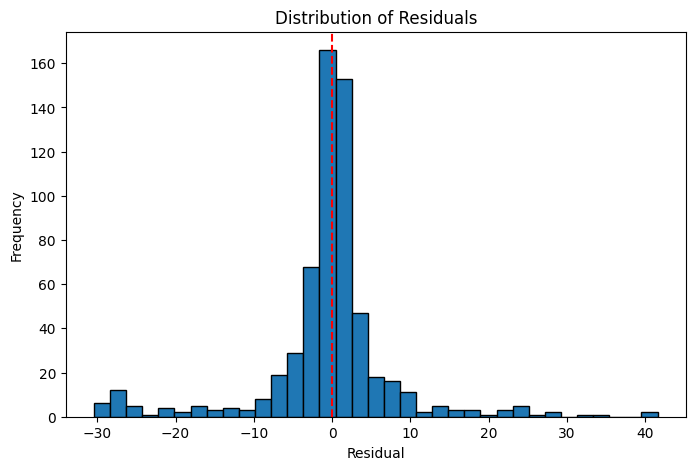

In [31]:
# Residual Distributions
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=35,
    edgecolor="black"
)

plt.axvline(0,color="red",linestyle="--")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

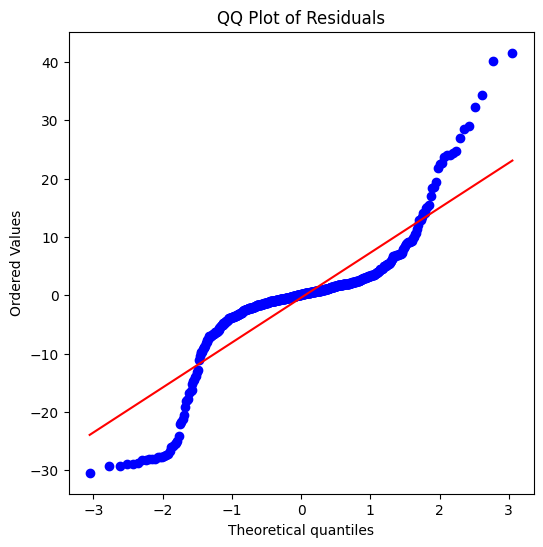

In [32]:
# QQ plot
from scipy import stats

plt.figure(figsize=(6,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Residuals")

plt.show()

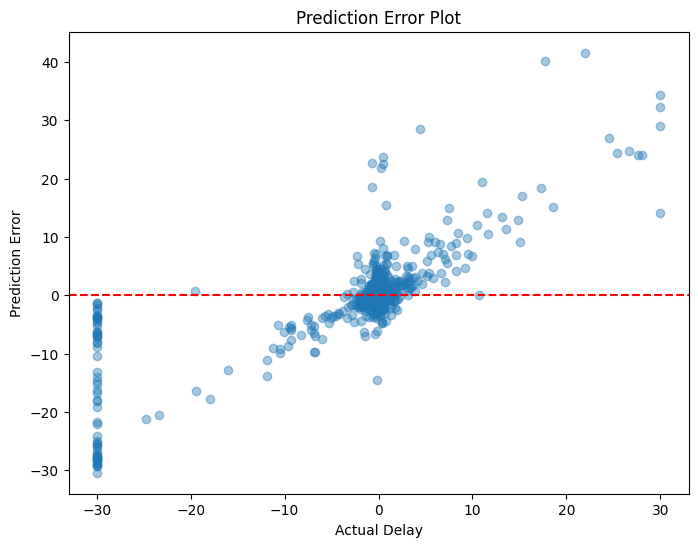

In [33]:
errors = y_test-rf_preds

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    errors,
    alpha=0.4
)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Actual Delay")
plt.ylabel("Prediction Error")

plt.title("Prediction Error Plot")

plt.show()

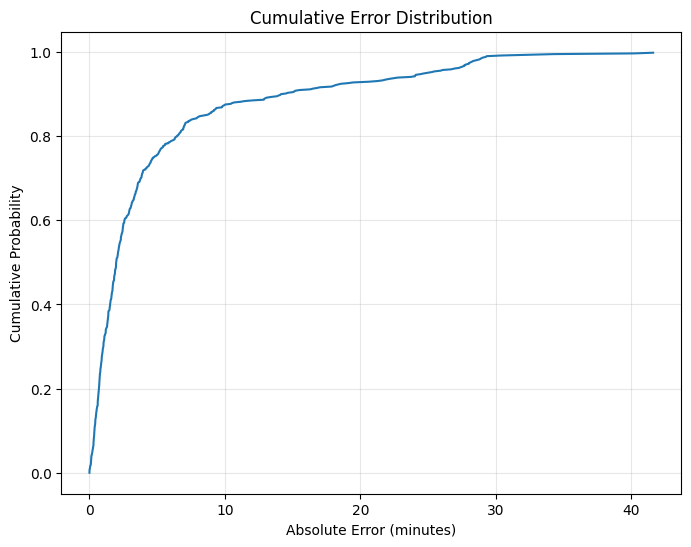

In [34]:
errors = np.abs(y_test-rf_preds)

errors = np.sort(errors)

cdf = np.arange(len(errors))/len(errors)

plt.figure(figsize=(8,6))

plt.plot(errors,cdf)

plt.xlabel("Absolute Error (minutes)")
plt.ylabel("Cumulative Probability")

plt.title("Cumulative Error Distribution")

plt.grid(alpha=0.3)

plt.show()

In [36]:
import joblib

joblib.dump(rf, "Models/random_forest_model.pkl")
print("Random Forest model saved.")
joblib.dump(scaler, "Models/scaler.pkl")
joblib.dump(route_encoder, "Models/route_encoder.pkl")
joblib.dump(agency_encoder, "Models/agency_encoder.pkl")
joblib.dump(features, "Models/features.pkl")

Random Forest model saved.


['Models/features.pkl']